In [1]:
import pandas as pd
import numpy as np
import random
import warnings
from utils import *
from datasets import *
from models import *

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Set display options
pd.set_option("display.max_rows", 500)  # Replace 500 with your desired number of rows
pd.set_option(
    "display.max_columns", 10
)  # Replace 10 with your desired number of columns
pd.set_option("display.width", 1000)  # Adjust the width as needed
pd.set_option("display.max_colwidth", 50)  # Adjust the column width as needed

### Data Preparation

In [2]:
# Prepare the data
# Adjust your path here
quality_df_dir = './results/quality_scores_per_subject.csv'
features_dir = "dataset_sample/features_df/"
info_dir = "dataset_sample/participant_info.csv"
clean_df, new_features, good_quality_sids = data_preparation(
    threshold = 0.2, 
    quality_df_dir = quality_df_dir,
    features_dir = features_dir,
    info_dir = info_dir)
print(clean_df.shape)
print(len(new_features))

(62977, 610)
597


### Split data to train, val, and test

In [3]:
SW_df, final_features = split_data(clean_df, good_quality_sids, new_features)
SW_df

,PPG_Rate_Mean,HRV_SDNN,HRV_MadNN,HRV_SDRMSSD,HRV_Prc20NN,...,Hypopnea,Multiple_Events,artifact,sid,BMI
239,89.219044,251.007707,208.490625,0.746030,487.500,...,0.0,0.0,0,S003,51.0
240,63.636527,470.681577,474.895312,0.980037,556.250,...,0.0,0.0,0,S003,51.0
241,83.848432,260.681456,254.821875,0.827994,496.875,...,0.0,0.0,0,S003,51.0
242,78.733011,231.806022,150.576562,0.757609,543.750,...,0.0,0.0,0,S003,51.0
243,74.423130,302.714148,324.318750,0.740854,553.125,...,0.0,0.0,0,S003,51.0
...,...,...,...,...,...,...,...,...,...,...,...
85066,61.392727,132.432765,23.165625,0.856175,1000.000,...,0.0,0.0,0,S102,26.0
85067,61.198295,138.500822,46.331250,1.081764,978.125,...,0.0,0.0,0,S102,26.0
85068,57.181574,18.233936,23.165625,0.781327,1031.250,...,0.0,0.0,0,S102,26.0
85069,57.535505,17.652470,23.165625,0.934502,1031.250,...,0.0,0.0,0,S102,26.0


In [4]:
import random
random.seed(0)
train_sids = random.sample(good_quality_sids, 56)
remaining_sids = [subj for subj in good_quality_sids if subj not in train_sids]
val_sids = random.sample(remaining_sids, 8)
test_sids = [subj for subj in remaining_sids if subj not in val_sids]

group_variables = ['AHI_Severity', 'Obesity']
# when idx == 0, it returns ['AHI_Severity'], the first variable in the list
# when idx == 1, it returns ['Obesity'], the second variable in the list
group_variable = get_variable(group_variables, idx = 0) # set your variable

In [5]:
X_train, y_train, group_train = train_test_split(SW_df, train_sids, final_features, group_variable)
print("Train data balance: ")
print(np.unique(y_train, return_counts=True))
print('')

X_val, y_val, group_val = train_test_split(SW_df, val_sids, final_features, group_variable)
print("Validation data balancpredicted_probabilitiese: ")
print(np.unique(y_val, return_counts=True))
print('')

X_test, y_test, group_test = train_test_split(SW_df, test_sids, final_features, group_variable)
print("Test data balance: ")
print(np.unique(y_test, return_counts=True))
print(y_train.sum())

Train data balance: 
(array([0., 1., 2., 3., 4.]), array([10698,  4666,  4320, 22209,  1868]))

Validation data balancpredicted_probabilitiese: 
(array([0., 1., 2., 3., 4.]), array([1366,  707, 1079, 3145,   70]))

Test data balance: 
(array([0., 1., 2., 3., 4.]), array([2447, 1674, 1395, 7028,  305]))
87405.0


### Resample data

In [6]:
X_train_resampled, y_train_resampled, group_train_resampled = resample_data(X_train, y_train, group_train, group_variable)

### LightGBM

In [7]:
final_lgb_model = LightGBM_engine(X_train_resampled, y_train_resampled, X_val, y_val)

100%|██████████| 100/100 [10:25<00:00,  6.26s/trial, best loss: -0.4296239862745794]
Best hyperparameters: {'boosting_type': 0, 'colsample_bytree': 0.8311532240730662, 'learning_rate': 0.09657461942436595, 'max_depth': 4.0, 'min_child_samples': 70.0, 'min_data_in_leaf': 20.0, 'n_estimators': 200.0, 'num_leaves': 40.0, 'reg_alpha': 70.0, 'reg_lambda': 10.877679756888528, 'subsample': 0.7571787237368456}
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20


/home/admin/miniconda3/envs/dreamt/lib/python3.10/site-packages/lightgbm/engine.py:172: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89679
[LightGBM] [Info] Number of data points in the train set: 43761, number of used features: 366
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.394151
[LightGBM] [Info] Start training from score -1.332823
[LightGBM] [Info] Start training from score -2.212790
[LightGBM] [Info] Start training from score -2.540239
[LightGBM] [Info] Start training from score -0.783563
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min

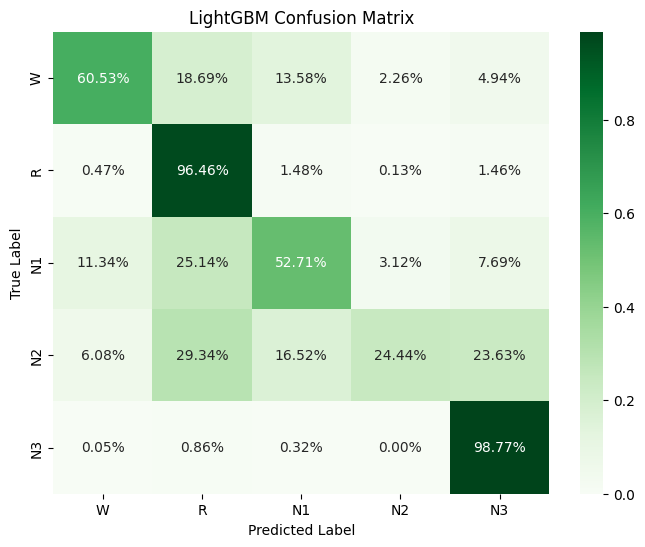

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=70 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min

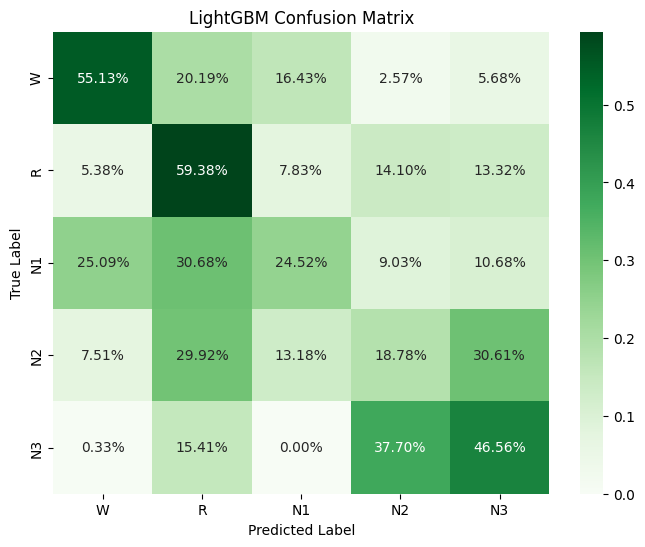

,Model,Precision,Recall,F1 Score,AUROC,Accuracy,Cohen's Kappa
0,LightGBM,0.552671,0.322749,0.340823,0.707754,0.322749,0.160842


In [8]:
# calculate training scores
prob_ls_train, len_train, true_ls_train = compute_probabilities(
    train_sids, SW_df, final_features, "lgb", final_lgb_model, group_variable)
lgb_train_results_df = LightGBM_result(final_lgb_model, X_train, y_train, prob_ls_train, true_ls_train)

# # calculate testing scores
prob_ls_test, len_test, true_ls_test = compute_probabilities(
    test_sids, SW_df, final_features, "lgb", final_lgb_model, group_variable)
lgb_test_results_df = LightGBM_result(final_lgb_model, X_test, y_test, prob_ls_test, true_ls_test)
lgb_test_results_df


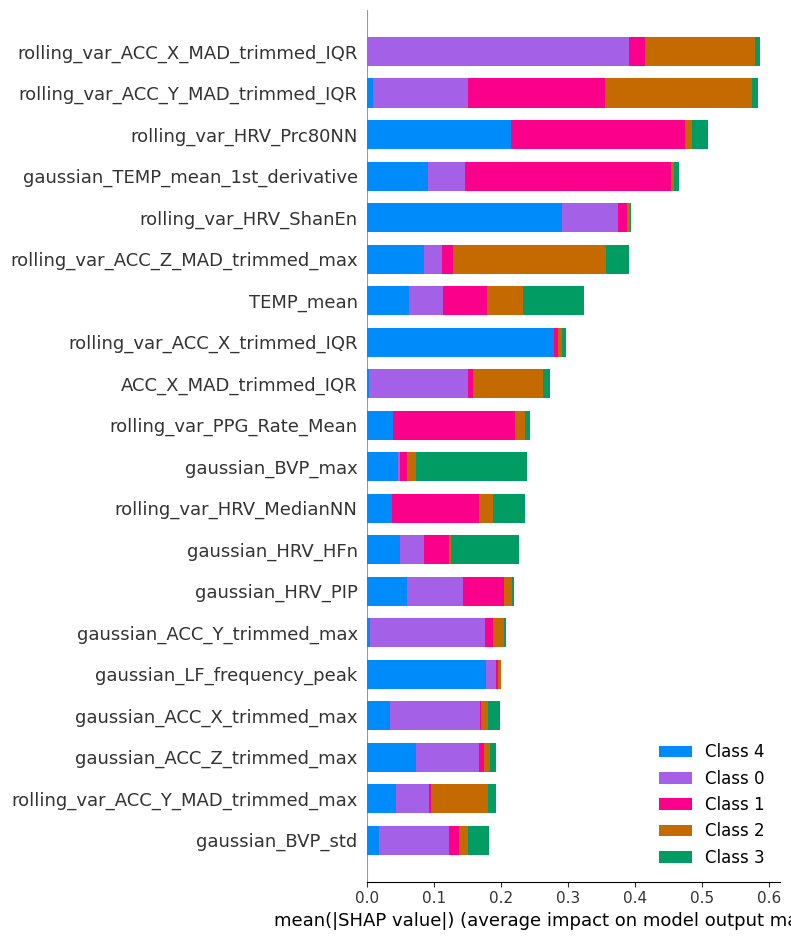

In [9]:
import shap
explainer = shap.TreeExplainer(final_lgb_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar", feature_names=final_features)

In [10]:
y_test

array([0., 0., 0., ..., 3., 0., 0.])

### LightGBM and LSTM post processing

In [11]:
dataloader_train = LSTM_dataloader(
    prob_ls_train, len_train, true_ls_train, batch_size=32
)

# Run LSTM model
LSTM_model = LSTM_engine(dataloader_train, num_epoch=300, hidden_layer_size=32, learning_rate=0.001) # set your num_epoch

Training on cpu
Epoch 5/300 - Loss: 13.8272, Accuracy: 0.0615
Epoch 10/300 - Loss: 11.8054, Accuracy: 0.0390
Epoch 15/300 - Loss: 10.4547, Accuracy: 0.1007
Epoch 20/300 - Loss: 7.9829, Accuracy: 0.1289
Epoch 25/300 - Loss: 6.5682, Accuracy: 0.1320
Epoch 30/300 - Loss: 5.8647, Accuracy: 0.2940
Epoch 35/300 - Loss: 5.5389, Accuracy: 0.2994
Epoch 40/300 - Loss: 5.2529, Accuracy: 0.2966
Epoch 45/300 - Loss: 4.9557, Accuracy: 0.3398
Epoch 50/300 - Loss: 4.6597, Accuracy: 0.3906
Epoch 55/300 - Loss: 4.4325, Accuracy: 0.4719
Epoch 60/300 - Loss: 4.2560, Accuracy: 0.4773
Epoch 65/300 - Loss: 4.1318, Accuracy: 0.4705
Epoch 70/300 - Loss: 4.0211, Accuracy: 0.4989
Epoch 75/300 - Loss: 3.9373, Accuracy: 0.5020
Epoch 80/300 - Loss: 3.8403, Accuracy: 0.6454
Epoch 85/300 - Loss: 3.7954, Accuracy: 0.6629
Epoch 90/300 - Loss: 3.7615, Accuracy: 0.6557
Epoch 95/300 - Loss: 3.7383, Accuracy: 0.6362
Epoch 100/300 - Loss: 3.6998, Accuracy: 0.6385
Epoch 105/300 - Loss: 3.6746, Accuracy: 0.6341
Epoch 110/300 

[[1523  131  551  207   35]
 [  29  526  356  686   77]
 [ 289  135  558  358   55]
 [ 550  684 1514 3196 1084]
 [   1   18    7  200   79]]


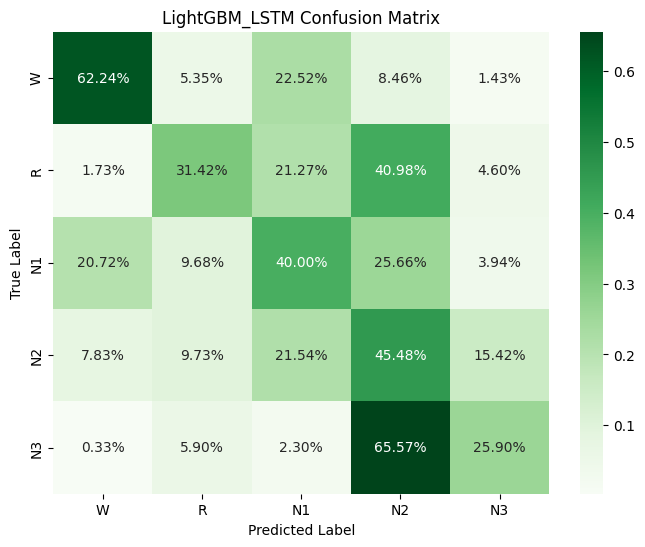

,Model,Precision,Recall,F1 Score,AUROC,Accuracy,Cohen's Kappa
0,LightGBM_LSTM,0.565004,0.457779,0.492554,0.725866,0.457779,0.218712


In [12]:
dataloader_test = LSTM_dataloader(
    prob_ls_test, len_test, true_ls_test, batch_size=1
)
lgb_lstm_test_results_df = LSTM_eval(LSTM_model, dataloader_test, true_ls_test, 'LightGBM_LSTM')
lgb_lstm_test_results_df

### GPBoosting

In [13]:
final_gpb_model = GPBoost_engine(X_train_resampled, group_train_resampled, y_train_resampled, X_val, y_val, group_val)

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

[GPBoost] [Fatal] Response variable (label) data needs to be 0 or 1 for likelihood of type 'bernoulli_probit' 
job exception: Response variable (label) data needs to be 0 or 1 for likelihood of type 'bernoulli_probit' 



  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]


GPBoostError: Response variable (label) data needs to be 0 or 1 for likelihood of type 'bernoulli_probit' 

In [ ]:
# calculate training scores
prob_ls_train, len_train, true_ls_train = compute_probabilities(
    train_sids, SW_df, final_features, 'gpb', final_gpb_model, group_variable)
gpb_train_results_df = GPBoost_result(final_gpb_model, X_train, y_train, group_train, prob_ls_train, true_ls_train)

# calculate testing scores
prob_ls_test, len_test, true_ls_test = compute_probabilities(
    test_sids, SW_df, final_features, 'gpb', final_gpb_model, group_variable)
gpb_test_results_df = GPBoost_result(final_gpb_model, X_test, y_test, group_test, prob_ls_test, true_ls_test)
gpb_test_results_df

### GPBoost + LSTM post processing

In [ ]:
dataloader_train = LSTM_dataloader(
    prob_ls_train, len_train, true_ls_train, batch_size=32
)

# Run LSTM model
LSTM_model = LSTM_engine(dataloader_train, num_epoch=300, hidden_layer_size=32, learning_rate = 0.001) # set your num_epoch

In [ ]:
dataloader_test = LSTM_dataloader(
    prob_ls_test, len_test, true_ls_test, batch_size=1
)

gpb_lstm_test_results_df = LSTM_eval(LSTM_model, dataloader_test, true_ls_test, 'GPBoost_LSTM')
gpb_lstm_test_results_df

In [ ]:
overall_result = pd.concat([lgb_test_results_df, lgb_lstm_test_results_df, 
                            gpb_test_results_df, gpb_lstm_test_results_df])
print(group_variable)
overall_result